# EDA 12.2: Installment Analysis

This notebook analyzes installment payment behavior, installment term and value patterns, whether installment usage is associated with premium or high-value products, and whether installment features look useful enough for forecasting or remain lower priority.

## 1. Setup and File Discovery

Locate required and optional CSV files under the current working directory. Missing files generate warnings and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['payments.csv', 'orders.csv', 'order_items.csv', 'products.csv', 'sales.csv']
REQUIRED = {'payments.csv', 'orders.csv'}

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,payments.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\pa...
1,orders.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
2,order_items.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
3,products.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
4,sales.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...


## 2. Load Payments, Orders, and Optional Files

Load all available inputs safely with pandas and display basic schema context.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
payments = data.get('payments')
orders = data.get('orders')
order_items = data.get('order_items')
products = data.get('products')
sales = data.get('sales')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

C:\Users\ACER\AppData\Local\Temp\ipykernel_14024\2663305443.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,dataset,loaded,rows,columns
0,payments,True,646945,"order_id, payment_method, payment_value, insta..."
1,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
2,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."
3,products,True,2412,"product_id, product_name, category, segment, s..."
4,sales,True,3833,"Date, Revenue, COGS"


## 3. Identify Payment, Order, Installment, Amount, Product, Category, Segment, and Date Columns

Use tolerant matching for naming variations. If payment date is missing in `payments.csv`, the notebook falls back to `orders.order_date`.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

def pick_numeric_value(df, candidates):
    col = find_column(df.columns, candidates, contains=True)
    if col is not None:
        return col
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    return numeric_cols[0] if numeric_cols else None

payment_cols = {}
if payments is not None:
    payment_cols = {
        'payment_id': find_column(payments.columns, ['payment_id', 'transaction_id', 'id'], contains=True),
        'order_id': find_column(payments.columns, ['order_id']),
        'payment_date': find_column(payments.columns, ['payment_date', 'transaction_date', 'date', 'created_at'], contains=True),
        'payment_method': find_column(payments.columns, ['payment_method', 'method', 'payment_type', 'payment_channel'], contains=True),
        'payment_amount': find_column(payments.columns, ['payment_amount', 'payment_value', 'amount', 'value', 'paid_amount'], contains=True),
        'payment_status': find_column(payments.columns, ['payment_status', 'status', 'transaction_status'], contains=True),
        'installment_count': find_column(payments.columns, ['installments', 'installment_count', 'number_of_installments', 'payment_terms', 'term_months', 'months', 'split_payment'], contains=True),
    }

orders_cols = {}
if orders is not None:
    orders_cols = {
        'order_id': find_column(orders.columns, ['order_id']),
        'order_date': find_column(orders.columns, ['order_date', 'date', 'created_at'], contains=True),
        'order_status': find_column(orders.columns, ['order_status', 'status'], contains=True),
        'order_total': find_column(orders.columns, ['order_total', 'revenue', 'amount', 'total', 'gmv'], contains=True),
    }

order_item_cols = {}
if order_items is not None:
    order_item_cols = {
        'order_id': find_column(order_items.columns, ['order_id']),
        'product_id': find_column(order_items.columns, ['product_id']),
        'quantity': find_column(order_items.columns, ['quantity', 'qty', 'units'], contains=True),
        'unit_price': find_column(order_items.columns, ['unit_price', 'price', 'selling_price'], contains=True),
        'discount_amount': find_column(order_items.columns, ['discount_amount', 'discount'], contains=True),
    }

product_cols = {}
if products is not None:
    product_cols = {
        'product_id': find_column(products.columns, ['product_id', 'sku']),
        'category': find_column(products.columns, ['category', 'product_category']),
        'segment': find_column(products.columns, ['segment', 'product_segment']),
        'product_price': find_column(products.columns, ['price', 'product_price', 'list_price'], contains=True),
        'premium_label': find_column(products.columns, ['premium', 'high_end', 'is_premium', 'tier'], contains=True),
    }

identified = pd.DataFrame({
    'payments': pd.Series(payment_cols),
    'orders': pd.Series(orders_cols),
    'order_items': pd.Series(order_item_cols),
    'products': pd.Series(product_cols),
})
display(identified)

if payments is not None and payment_cols.get('installment_count') is None:
    warnings.warn('Installment field could not be identified reliably. Installment-specific analysis may be skipped.')

,payments,orders,order_items,products
category,NaN,NaN,NaN,category
discount_amount,NaN,NaN,discount_amount,NaN
installment_count,installments,NaN,NaN,NaN
order_date,NaN,order_date,NaN,NaN
order_id,order_id,order_id,order_id,NaN
order_status,NaN,order_status,NaN,NaN
order_total,NaN,None,NaN,NaN
payment_amount,payment_value,NaN,NaN,NaN
payment_date,None,NaN,NaN,NaN
payment_id,order_id,NaN,NaN,NaN


## 4. Payment and Installment Data Quality Checks

Standardize installment values, payment value, dates, and method labels. Flag invalid installment counts and other anomalies.

In [4]:
installment_warnings = []
payments_clean = None

def standardize_payment_method(value):
    if pd.isna(value):
        return np.nan
    raw = str(value).strip().lower()
    raw = re.sub(r'[^a-z0-9]+', '_', raw).strip('_')
    mapping = {
        'creditcard': 'credit_card',
        'credit_card': 'credit_card',
        'card': 'credit_card',
        'cod': 'cod',
        'cash_on_delivery': 'cod',
        'banktransfer': 'bank_transfer',
        'bank_transfer': 'bank_transfer',
        'applepay': 'apple_pay',
        'apple_pay': 'apple_pay',
        'paypal': 'paypal',
    }
    return mapping.get(raw, raw)

if payments is not None:
    payments_clean = payments.copy()
    payments_clean['order_id_std'] = payments_clean[payment_cols['order_id']] if payment_cols.get('order_id') else pd.NA
    payments_clean['payment_method_std'] = payments_clean[payment_cols['payment_method']].map(standardize_payment_method) if payment_cols.get('payment_method') else np.nan
    payments_clean['payment_amount_std'] = pd.to_numeric(payments_clean[payment_cols['payment_amount']], errors='coerce') if payment_cols.get('payment_amount') else np.nan
    payments_clean['payment_date_std'] = pd.to_datetime(payments_clean[payment_cols['payment_date']], errors='coerce') if payment_cols.get('payment_date') else pd.NaT
    payments_clean['payment_status_std'] = payments_clean[payment_cols['payment_status']].astype(str).str.strip().str.lower() if payment_cols.get('payment_status') else pd.NA
    payments_clean['payment_id_std'] = payments_clean[payment_cols['payment_id']] if payment_cols.get('payment_id') else pd.NA
    payments_clean['installment_term'] = pd.to_numeric(payments_clean[payment_cols['installment_count']], errors='coerce') if payment_cols.get('installment_count') else np.nan
    payments_clean['is_installment_payment'] = payments_clean['installment_term'].gt(1)

    invalid_installment_mask = payments_clean['installment_term'].notna() & (
        (payments_clean['installment_term'] < 0) | (payments_clean['installment_term'] != np.floor(payments_clean['installment_term']))
    )
    zero_installment_with_value = payments_clean['installment_term'].fillna(0).eq(0) & payments_clean['payment_amount_std'].notna()
    large_installment_mask = payments_clean['installment_term'].fillna(0).gt(24)
    duplicate_order_payment = int(payments_clean.duplicated(subset=[c for c in ['order_id_std', 'payment_method_std', 'payment_amount_std', 'installment_term'] if c in payments_clean.columns]).sum())

    quality = pd.DataFrame([{
        'payment_rows': len(payments_clean),
        'installment_payment_rows': int(payments_clean['is_installment_payment'].fillna(False).sum()),
        'installment_usage_rate': payments_clean['is_installment_payment'].fillna(False).mean(),
        'missing_installment_values': int(payments_clean['installment_term'].isna().sum()),
        'invalid_installment_values': int(invalid_installment_mask.sum()),
        'payment_date_min': payments_clean['payment_date_std'].min(),
        'payment_date_max': payments_clean['payment_date_std'].max(),
        'missing_payment_amounts': int(payments_clean['payment_amount_std'].isna().sum()),
        'duplicate_order_payment_records': duplicate_order_payment,
        'zero_or_negative_payment_amounts': int(payments_clean['payment_amount_std'].fillna(0).le(0).sum()),
        'installment_term_zero_with_value': int(zero_installment_with_value.sum()),
        'very_large_installment_terms': int(large_installment_mask.sum()),
    }])
    display(quality)
    display(payments_clean['installment_term'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).to_frame('installment_term_summary'))
    display(payments_clean['payment_amount_std'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).to_frame('payment_amount_summary'))

    if quality.loc[0, 'missing_installment_values'] > 0:
        installment_warnings.append(f"{quality.loc[0, 'missing_installment_values']} payment rows have missing installment values")
    if quality.loc[0, 'invalid_installment_values'] > 0:
        installment_warnings.append(f"{quality.loc[0, 'invalid_installment_values']} payment rows have invalid installment values")
else:
    warnings.warn('payments.csv not available.')

,payment_rows,installment_payment_rows,installment_usage_rate,missing_installment_values,invalid_installment_values,payment_date_min,payment_date_max,missing_payment_amounts,duplicate_order_payment_records,zero_or_negative_payment_amounts,installment_term_zero_with_value,very_large_installment_terms
0,646945,384079,0.5937,0,0,NaT,NaT,0,0,0,0,0


,installment_term_summary
count,"646,945.0000"
mean,3.4483
std,3.1196
min,1.0000
25%,1.0000
50%,3.0000
75%,6.0000
90%,6.0000
max,12.0000


,payment_amount_summary
count,"646,945.0000"
mean,"24,238.3344"
std,"22,378.4753"
min,389.7400
25%,"7,681.0600"
50%,"17,229.4400"
75%,"33,706.3500"
90%,"55,476.3000"
max,"331,570.4000"


## 5. Join Payments with Orders

Join `payments` to `orders` on `order_id` and use `orders.order_date` when payment date is unavailable.

In [5]:
orders_clean = None
payments_orders = pd.DataFrame()
join_warnings = []

if orders is not None:
    orders_clean = orders.copy()
    orders_clean['order_id_std'] = orders_clean[orders_cols['order_id']] if orders_cols.get('order_id') else pd.NA
    orders_clean['order_date_std'] = pd.to_datetime(orders_clean[orders_cols['order_date']], errors='coerce') if orders_cols.get('order_date') else pd.NaT
    orders_clean['order_status_std'] = orders_clean[orders_cols['order_status']].astype(str).str.strip().str.lower() if orders_cols.get('order_status') else pd.NA
    orders_clean['order_total_std'] = pd.to_numeric(orders_clean[orders_cols['order_total']], errors='coerce') if orders_cols.get('order_total') else np.nan

if payments_clean is not None and orders_clean is not None:
    keep_cols = ['order_id_std', 'order_date_std', 'order_status_std', 'order_total_std']
    payments_orders = payments_clean.merge(orders_clean[keep_cols], on='order_id_std', how='left', indicator=True)
    if payment_cols.get('payment_date') is None:
        payments_orders['payment_date_std'] = payments_orders['order_date_std']
    if payment_cols.get('payment_amount') is None and orders_cols.get('order_total'):
        payments_orders['payment_amount_std'] = payments_orders['order_total_std']

    join_quality = pd.DataFrame([{
        'payment_rows_matched_to_orders': int((payments_orders['_merge'] == 'both').sum()),
        'payment_rows_unmatched_to_orders': int((payments_orders['_merge'] == 'left_only').sum()),
        'orders_without_payment_records': int((~orders_clean['order_id_std'].isin(payments_clean['order_id_std'])).sum()),
        'orders_with_duplicate_payments': int(payments_orders.groupby('order_id_std').size().gt(1).sum()),
    }])
    display(join_quality)
    if join_quality.loc[0, 'payment_rows_unmatched_to_orders'] > 0:
        join_warnings.append(f"{join_quality.loc[0, 'payment_rows_unmatched_to_orders']} payment rows did not match orders")
else:
    payments_orders = payments_clean.copy() if payments_clean is not None else pd.DataFrame()

,payment_rows_matched_to_orders,payment_rows_unmatched_to_orders,orders_without_payment_records,orders_with_duplicate_payments
0,646945,0,0,0


## 6. Payment Value by Installment Term

Compare payment count, payment share, total payment value, and average payment value across installment terms.

,installment_term,payment_count,total_payment_value,avg_payment_value,median_payment_value,p75_payment_value,p90_payment_value,payment_share,payment_value_share
0,1,262866,"6,338,559,926.8500","24,113.2742","17,088.8850","33,571.5875","55,374.0500",0.4063,0.4042
1,2,1094,"775,070.2600",708.4737,722.3000,804.3850,844.4480,0.0017,0.0000
2,3,218949,"5,342,275,790.0500","24,399.6355","17,366.7200","33,893.3400","55,612.1700",0.3384,0.3407
3,6,109910,"2,686,931,785.4300","24,446.6544","17,451.9650","33,905.2700","55,799.3670",0.1699,0.1714
4,12,54126,"1,312,326,692.8400","24,245.7727","17,336.7500","33,571.8000","55,139.1300",0.0837,0.0837


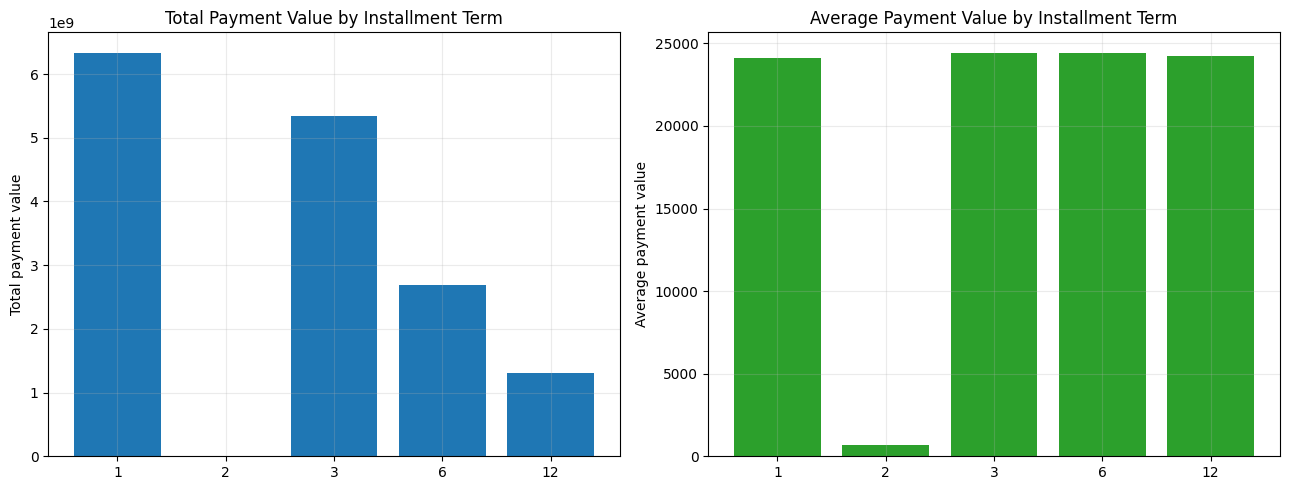

In [6]:
term_summary = pd.DataFrame()

if not payments_orders.empty and 'installment_term' in payments_orders.columns:
    term_summary = payments_orders.groupby('installment_term').agg(
        payment_count=('order_id_std', 'size'),
        total_payment_value=('payment_amount_std', 'sum'),
        avg_payment_value=('payment_amount_std', 'mean'),
        median_payment_value=('payment_amount_std', 'median'),
        p75_payment_value=('payment_amount_std', lambda s: s.quantile(0.75)),
        p90_payment_value=('payment_amount_std', lambda s: s.quantile(0.90)),
    ).reset_index().sort_values('payment_count', ascending=False)
    term_summary['payment_share'] = term_summary['payment_count'] / term_summary['payment_count'].sum()
    term_summary['payment_value_share'] = term_summary['total_payment_value'] / term_summary['total_payment_value'].sum()
    display(term_summary.sort_values('installment_term'))

    ordered = term_summary.sort_values('installment_term')
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].bar(ordered['installment_term'].astype(str), ordered['total_payment_value'], color='tab:blue')
    axes[0].set_title('Total Payment Value by Installment Term')
    axes[0].set_ylabel('Total payment value')
    axes[1].bar(ordered['installment_term'].astype(str), ordered['avg_payment_value'], color='tab:green')
    axes[1].set_title('Average Payment Value by Installment Term')
    axes[1].set_ylabel('Average payment value')
    plt.tight_layout()
    plt.show()
else:
    print('Installment-term summary cannot be built because installment_term is unavailable.')

## 7. Installment Usage Over Time

Aggregate installment usage by month and inspect whether installment usage increases, decreases, or stays stable.

,month,total_payment_value,payment_count,installment_payment_count,total_installment_payment_value,avg_installment_payment_value,avg_installment_term,installment_usage_rate,most_common_term
0,2012-07-01,"130,406,773.5100",5294,3194,"77,509,659.2500","24,267.2696",3.5244,0.6033,1
1,2012-08-01,"159,089,240.3100",6427,3878,"95,255,716.3000","24,563.1037",3.4380,0.6034,1
2,2012-09-01,"129,307,133.8200",5219,3086,"76,629,555.4200","24,831.3530",3.4307,0.5913,1
3,2012-10-01,"110,185,694.4500",4285,2494,"63,604,137.5900","25,502.8619",3.4495,0.5820,1
4,2012-11-01,"98,186,295.2400",4142,2467,"59,477,347.4100","24,109.1801",3.4648,0.5956,1
5,2012-12-01,"114,322,610.6900",6684,3836,"66,470,219.0100","17,328.0029",3.3682,0.5739,1
6,2013-01-01,"91,285,449.8900",3665,2192,"55,442,817.3600","25,293.2561",3.4188,0.5981,1
7,2013-02-01,"106,360,669.3000",4661,2801,"64,684,966.5700","23,093.5261",3.4647,0.6009,1
8,2013-03-01,"141,545,691.4000",6590,3913,"84,967,478.0300","21,714.1523",3.4608,0.5938,1
9,2013-04-01,"189,651,816.0100",8874,5244,"112,976,603.5200","21,543.9747",3.4751,0.5909,1


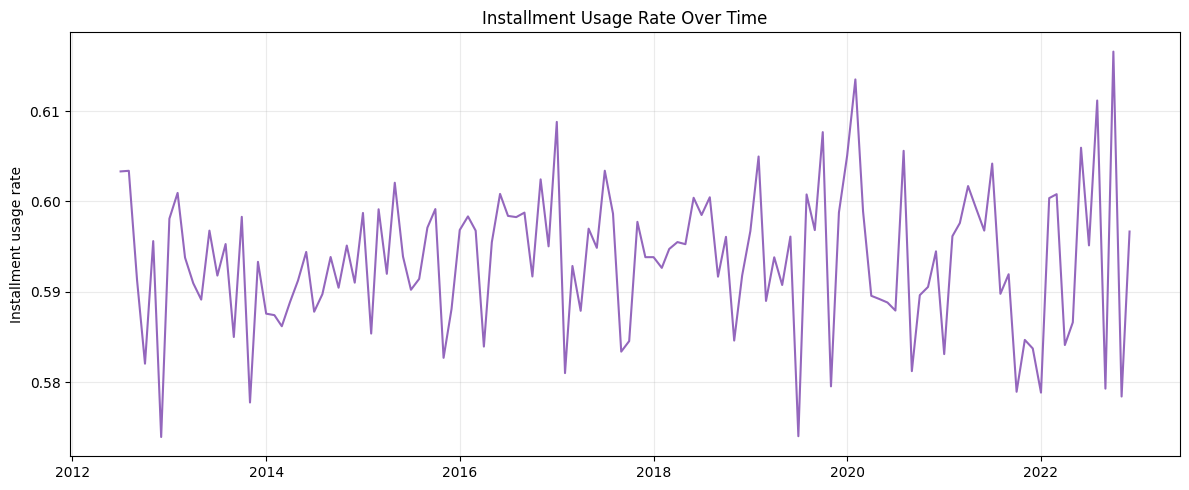

In [7]:
monthly_installment = pd.DataFrame()

if not payments_orders.empty and payments_orders['payment_date_std'].notna().any():
    pay = payments_orders.dropna(subset=['payment_date_std']).copy()
    pay['month'] = pay['payment_date_std'].dt.to_period('M').dt.to_timestamp()
    monthly_installment = pay.groupby('month').agg(
        total_payment_value=('payment_amount_std', 'sum'),
        payment_count=('order_id_std', 'size'),
        installment_payment_count=('is_installment_payment', 'sum'),
        total_installment_payment_value=('payment_amount_std', lambda s: s[pay.loc[s.index, 'is_installment_payment']].sum()),
        avg_installment_payment_value=('payment_amount_std', lambda s: s[pay.loc[s.index, 'is_installment_payment']].mean()),
        avg_installment_term=('installment_term', 'mean'),
    ).reset_index()
    monthly_installment['installment_usage_rate'] = np.where(
        monthly_installment['payment_count'] > 0,
        monthly_installment['installment_payment_count'] / monthly_installment['payment_count'],
        np.nan
    )
    common_term = pay.groupby(['month', 'installment_term']).size().reset_index(name='n')
    common_term = common_term.sort_values(['month', 'n', 'installment_term'], ascending=[True, False, True]).drop_duplicates('month')
    monthly_installment = monthly_installment.merge(common_term[['month', 'installment_term']].rename(columns={'installment_term': 'most_common_term'}), on='month', how='left')
    display(monthly_installment.head(12))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_installment['month'], monthly_installment['installment_usage_rate'], color='tab:purple')
    ax.set_title('Installment Usage Rate Over Time')
    ax.set_ylabel('Installment usage rate')
    plt.tight_layout()
    plt.show()
else:
    print('Installment usage over time cannot be built because payment or fallback order dates are unavailable.')

## 8. Installment Usage and AOV or Revenue

Build an order-level view and compare installment vs non-installment orders using payment value as the order-value proxy.

,is_installment_payment,order_count,total_value,avg_order_value,median_order_value,avg_installment_term,order_type
0,False,262866,"6,338,559,926.8500","24,113.2742","17,088.8850",1.0000,non_installment
1,True,384079,"9,342,309,338.5800","24,323.9264","17,326.4400",5.1240,installment


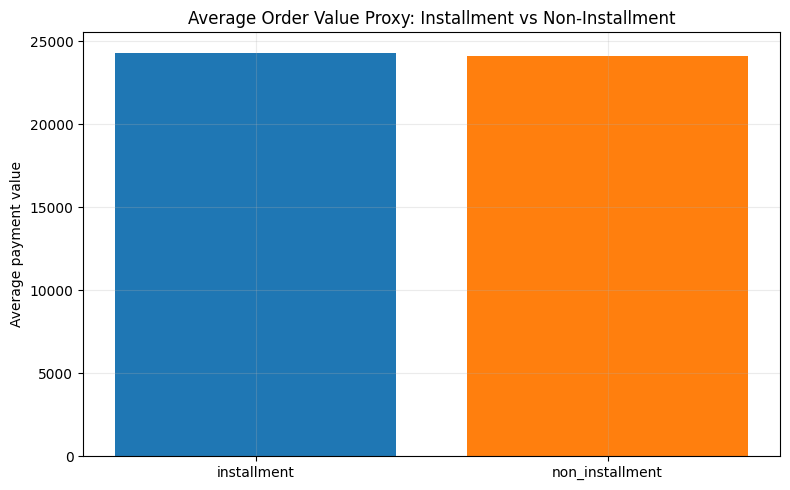

In [8]:
aov_summary = pd.DataFrame()

if not payments_orders.empty:
    order_level = payments_orders.copy()
    order_level['order_value_proxy'] = order_level['payment_amount_std']
    aov_summary = order_level.groupby('is_installment_payment').agg(
        order_count=('order_id_std', 'nunique'),
        total_value=('order_value_proxy', 'sum'),
        avg_order_value=('order_value_proxy', 'mean'),
        median_order_value=('order_value_proxy', 'median'),
        avg_installment_term=('installment_term', 'mean'),
    ).reset_index()
    aov_summary['order_type'] = np.where(aov_summary['is_installment_payment'], 'installment', 'non_installment')
    display(aov_summary)

    fig, ax = plt.subplots(figsize=(8, 5))
    ordered = aov_summary.sort_values('order_type')
    ax.bar(ordered['order_type'], ordered['avg_order_value'], color=['tab:blue', 'tab:orange'])
    ax.set_title('Average Order Value Proxy: Installment vs Non-Installment')
    ax.set_ylabel('Average payment value')
    plt.tight_layout()
    plt.show()
else:
    print('AOV comparison is unavailable because order-level payment data could not be prepared.')

## 9. Installment and Premium or High-End Products

Use `order_items` and `products` where available. If no premium label exists, create a proxy from product price or order value percentiles and label it clearly.

,is_premium_proxy,item_rows,installment_usage_rate,avg_installment_term,avg_item_value,group
0,False,570905,0.5925,3.4450,"16,239.7456",regular
1,True,143764,0.5973,3.4636,"49,797.7562",premium_or_high_value


Premium/high-end indicator is a proxy: product price in the top 20% (threshold 9,577.15).


,category,item_rows,installment_usage_rate,avg_installment_term,avg_item_value
3,Streetwear,393533,0.5968,3.4700,"33,367.8404"
0,Casual,23991,0.5966,3.4556,"19,200.8830"
1,GenZ,37159,0.5907,3.4252,"9,246.7261"
2,Outdoor,259986,0.5886,3.4193,"9,596.2196"


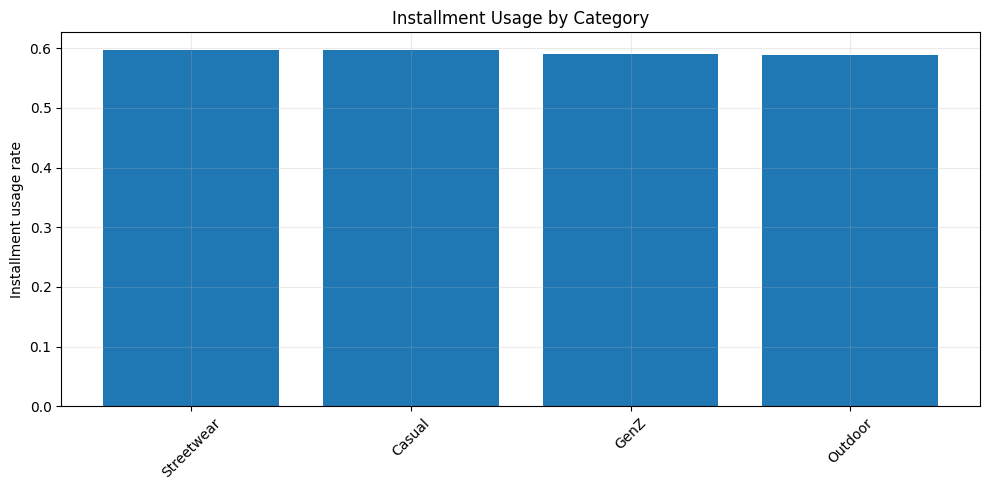

,segment,item_rows,installment_usage_rate,avg_installment_term,avg_item_value
6,Standard,10937,0.5991,3.4687,"21,640.0426"
3,Everyday,182533,0.5982,3.4828,"29,456.8580"
1,All-weather,22570,0.5965,3.4556,"18,944.8172"
2,Balanced,103333,0.5961,3.4585,"49,620.2426"
4,Performance,96730,0.5948,3.4584,"24,712.2095"
7,Trendy,37159,0.5907,3.4252,"9,246.7261"
5,Premium,31032,0.5887,3.4189,"15,472.1381"
0,Activewear,230375,0.5886,3.4196,"8,889.0514"


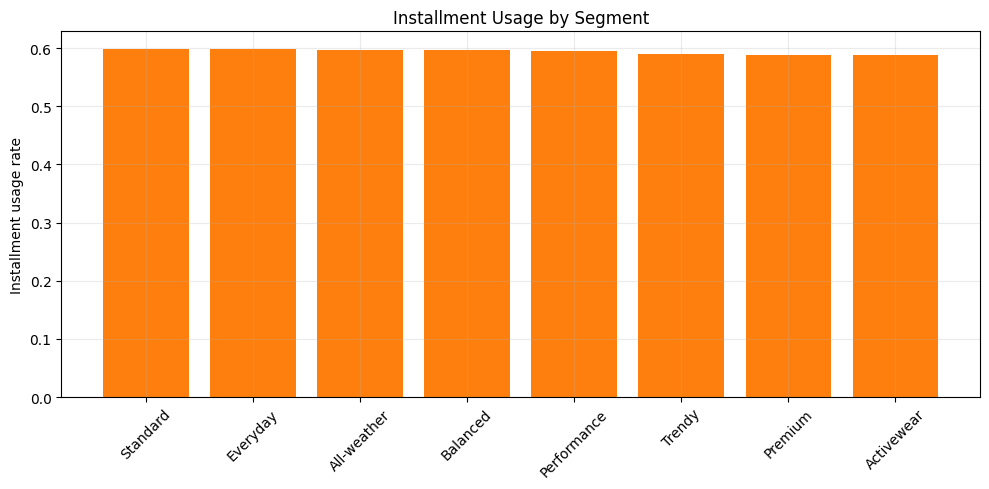

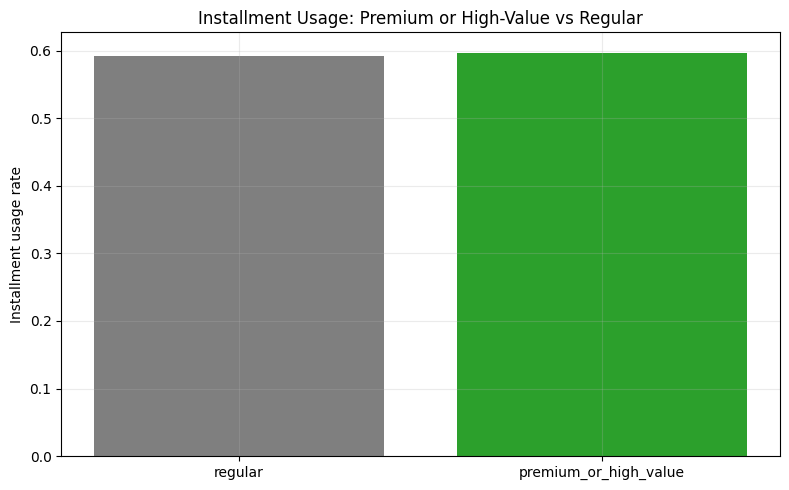

In [9]:
order_item_enriched = pd.DataFrame()
category_installment = pd.DataFrame()
segment_installment = pd.DataFrame()
premium_summary = pd.DataFrame()
premium_proxy_note = ''

if payments_orders is not None and not payments_orders.empty and order_items is not None and products is not None and order_item_cols.get('order_id') and order_item_cols.get('product_id') and product_cols.get('product_id'):
    oi = order_items.copy()
    oi['order_id_std'] = oi[order_item_cols['order_id']]
    oi['product_id_std'] = oi[order_item_cols['product_id']]
    oi['quantity_std'] = pd.to_numeric(oi[order_item_cols['quantity']], errors='coerce') if order_item_cols.get('quantity') else np.nan
    oi['unit_price_std'] = pd.to_numeric(oi[order_item_cols['unit_price']], errors='coerce') if order_item_cols.get('unit_price') else np.nan
    oi['discount_amount_std'] = pd.to_numeric(oi[order_item_cols['discount_amount']], errors='coerce').fillna(0) if order_item_cols.get('discount_amount') else 0
    oi['item_value_std'] = oi['quantity_std'] * oi['unit_price_std']

    prod_keep = [product_cols['product_id']]
    rename_map = {product_cols['product_id']: 'product_id_std'}
    for label in ['category', 'segment', 'product_price', 'premium_label']:
        col = product_cols.get(label)
        if col:
            prod_keep.append(col)
            rename_map[col] = label
    prod = products[prod_keep].rename(columns=rename_map).copy()
    if 'product_price' in prod.columns:
        prod['product_price'] = pd.to_numeric(prod['product_price'], errors='coerce')
    if 'premium_label' in prod.columns:
        prod['premium_label_std'] = prod['premium_label']

    order_item_enriched = oi.merge(prod, on='product_id_std', how='left')
    order_item_enriched = order_item_enriched.merge(
        payments_orders[['order_id_std', 'payment_amount_std', 'installment_term', 'is_installment_payment', 'payment_date_std']],
        on='order_id_std',
        how='left'
    )

    if 'premium_label_std' in order_item_enriched.columns and order_item_enriched['premium_label_std'].notna().any():
        order_item_enriched['is_premium_proxy'] = order_item_enriched['premium_label_std'].astype(str).str.lower().isin(['1', 'true', 'yes', 'premium', 'high', 'high_end'])
        premium_proxy_note = 'Premium/high-end indicator uses the existing product premium label.'
    elif 'product_price' in order_item_enriched.columns and order_item_enriched['product_price'].notna().any():
        threshold = order_item_enriched['product_price'].quantile(0.80)
        order_item_enriched['is_premium_proxy'] = order_item_enriched['product_price'] >= threshold
        premium_proxy_note = f'Premium/high-end indicator is a proxy: product price in the top 20% (threshold {threshold:,.2f}).'
    else:
        threshold = order_item_enriched['item_value_std'].quantile(0.80)
        order_item_enriched['is_premium_proxy'] = order_item_enriched['item_value_std'] >= threshold
        premium_proxy_note = f'Premium/high-end indicator is a proxy: item value in the top 20% (threshold {threshold:,.2f}).'

    premium_summary = order_item_enriched.groupby('is_premium_proxy').agg(
        item_rows=('product_id_std', 'size'),
        installment_usage_rate=('is_installment_payment', 'mean'),
        avg_installment_term=('installment_term', 'mean'),
        avg_item_value=('item_value_std', 'mean'),
    ).reset_index()
    premium_summary['group'] = np.where(premium_summary['is_premium_proxy'], 'premium_or_high_value', 'regular')
    display(premium_summary)
    print(premium_proxy_note)

    if 'category' in order_item_enriched.columns:
        category_installment = order_item_enriched.groupby('category').agg(
            item_rows=('product_id_std', 'size'),
            installment_usage_rate=('is_installment_payment', 'mean'),
            avg_installment_term=('installment_term', 'mean'),
            avg_item_value=('item_value_std', 'mean'),
        ).reset_index().sort_values('installment_usage_rate', ascending=False)
        display(category_installment)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(category_installment['category'].astype(str), category_installment['installment_usage_rate'], color='tab:blue')
        ax.set_title('Installment Usage by Category')
        ax.set_ylabel('Installment usage rate')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

    if 'segment' in order_item_enriched.columns:
        segment_installment = order_item_enriched.groupby('segment').agg(
            item_rows=('product_id_std', 'size'),
            installment_usage_rate=('is_installment_payment', 'mean'),
            avg_installment_term=('installment_term', 'mean'),
            avg_item_value=('item_value_std', 'mean'),
        ).reset_index().sort_values('installment_usage_rate', ascending=False)
        display(segment_installment)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(segment_installment['segment'].astype(str), segment_installment['installment_usage_rate'], color='tab:orange')
        ax.set_title('Installment Usage by Segment')
        ax.set_ylabel('Installment usage rate')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(premium_summary['group'], premium_summary['installment_usage_rate'], color=['tab:gray', 'tab:green'])
    ax.set_title('Installment Usage: Premium or High-Value vs Regular')
    ax.set_ylabel('Installment usage rate')
    plt.tight_layout()
    plt.show()
else:
    print('Premium/high-end installment analysis is unavailable because order_items or products could not be linked.')

## 10. Installment Term and Product Mix

Where product data exists, examine installment term distribution and payment behavior by category or segment.

,category,installment_term,item_rows,installment_payment_value
0,Casual,1,9679,"186,651,115.6600"
1,Casual,3,8250,"158,334,612.7200"
2,Casual,6,4045,"77,861,141.8800"
3,Casual,12,2017,"37,801,513.0900"
4,GenZ,1,15208,"139,627,777.9000"
5,GenZ,2,55,"52,547.5000"
6,GenZ,3,12572,"117,160,349.6600"
7,GenZ,6,6274,"58,251,171.5700"
8,GenZ,12,3050,"28,507,248.7300"
9,Outdoor,1,106969,"1,019,085,324.4600"


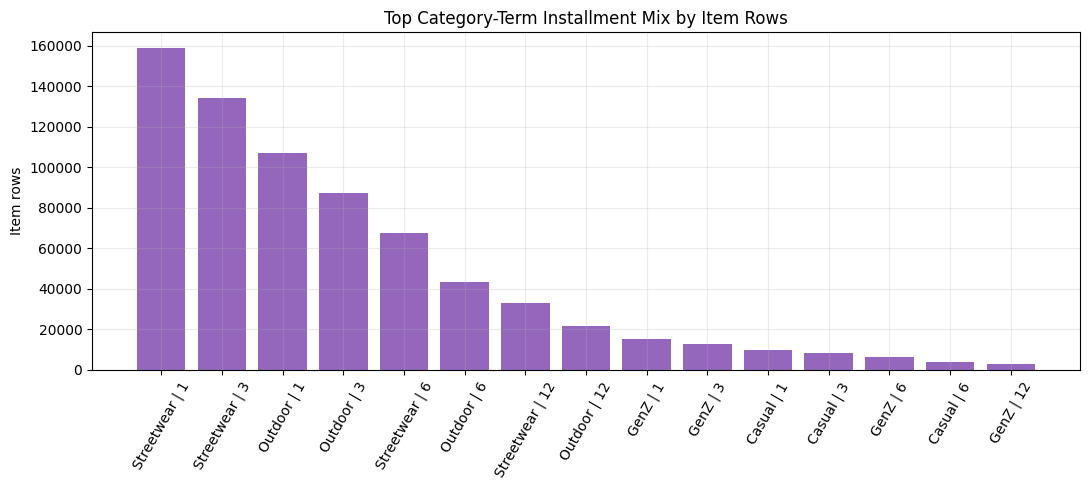

In [10]:
term_product_mix = pd.DataFrame()

if not order_item_enriched.empty and 'category' in order_item_enriched.columns:
    term_product_mix = order_item_enriched.groupby(['category', 'installment_term']).agg(
        item_rows=('product_id_std', 'size'),
        installment_payment_value=('item_value_std', 'sum'),
    ).reset_index()
    display(term_product_mix.head(20))

    top_cat_terms = term_product_mix.sort_values('item_rows', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(11, 5))
    labels = top_cat_terms['category'].astype(str) + ' | ' + top_cat_terms['installment_term'].astype(str)
    ax.bar(labels, top_cat_terms['item_rows'], color='tab:purple')
    ax.set_title('Top Category-Term Installment Mix by Item Rows')
    ax.set_ylabel('Item rows')
    ax.tick_params(axis='x', rotation=60)
    plt.tight_layout()
    plt.show()
else:
    print('Installment term and product-mix analysis is unavailable because category or item linkage is missing.')

## 11. Leakage-Safe Installment Forecast Feature Preview

Build lagged historical installment features only. Installment behavior is usually lower-priority unless it shows a stable relationship with Revenue or AOV.

In [11]:
feature_preview = pd.DataFrame()

if not monthly_installment.empty:
    feat = monthly_installment.sort_values('month').copy()
    feat['installment_usage_rate_lag'] = feat['installment_usage_rate'].shift(1)
    feat['avg_installment_payment_value_lag'] = feat['avg_installment_payment_value'].shift(1)
    feat['avg_installment_term_lag'] = feat['avg_installment_term'].shift(1)
    feat['installment_usage_roll_mean_3m'] = feat['installment_usage_rate'].shift(1).rolling(3, min_periods=1).mean()

    if not payments_orders.empty and payments_orders['payment_date_std'].notna().any():
        pay = payments_orders.dropna(subset=['payment_date_std']).copy()
        pay['month'] = pay['payment_date_std'].dt.to_period('M').dt.to_timestamp()
        for term in sorted(pay['installment_term'].dropna().unique()):
            tmp = pay.groupby(['month', 'installment_term']).size().reset_index(name='n')
            month_total = tmp.groupby('month')['n'].sum().rename('month_total')
            tmp = tmp.merge(month_total, on='month', how='left')
            tmp = tmp[tmp['installment_term'] == term].copy()
            tmp[f'term_{int(term)}_share'] = tmp['n'] / tmp['month_total']
            feat = feat.merge(tmp[['month', f'term_{int(term)}_share']], on='month', how='left')
            feat[f'term_{int(term)}_share_lag'] = feat[f'term_{int(term)}_share'].fillna(0).shift(1)

    preview_cols = [
        'month', 'total_payment_value', 'payment_count', 'installment_payment_count',
        'installment_usage_rate', 'avg_installment_payment_value', 'avg_installment_term',
        'installment_usage_rate_lag', 'avg_installment_payment_value_lag',
        'avg_installment_term_lag', 'installment_usage_roll_mean_3m'
    ]
    preview_cols += [c for c in feat.columns if c.endswith('_share_lag')]
    feature_preview = feat[preview_cols].head(20)
    display(feature_preview)

print('Installment features shown above are lagged historical aggregates only.')
print('Treat installment features as optional or lower-priority unless they show a stable relationship with Revenue or AOV.')
print('Do not use current-period or future installment behavior directly unless it is genuinely known before prediction.')

,month,total_payment_value,payment_count,installment_payment_count,installment_usage_rate,avg_installment_payment_value,avg_installment_term,installment_usage_rate_lag,avg_installment_payment_value_lag,avg_installment_term_lag,installment_usage_roll_mean_3m,term_1_share_lag,term_2_share_lag,term_3_share_lag,term_6_share_lag,term_12_share_lag
0,2012-07-01,"130,406,773.5100",5294,3194,0.6033,"24,267.2696",3.5244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-08-01,"159,089,240.3100",6427,3878,0.6034,"24,563.1037",3.4380,0.6033,"24,267.2696",3.5244,0.6033,0.3967,0.0009,0.3411,0.1721,0.0892
2,2012-09-01,"129,307,133.8200",5219,3086,0.5913,"24,831.3530",3.4307,0.6034,"24,563.1037",3.4380,0.6034,0.3966,0.0016,0.3499,0.1724,0.0795
3,2012-10-01,"110,185,694.4500",4285,2494,0.5820,"25,502.8619",3.4495,0.5913,"24,831.3530",3.4307,0.5993,0.4087,0.0010,0.3384,0.1698,0.0822
4,2012-11-01,"98,186,295.2400",4142,2467,0.5956,"24,109.1801",3.4648,0.5820,"25,502.8619",3.4495,0.5922,0.4180,0.0021,0.3281,0.1631,0.0887
5,2012-12-01,"114,322,610.6900",6684,3836,0.5739,"17,328.0029",3.3682,0.5956,"24,109.1801",3.4648,0.5896,0.4044,0.0034,0.3394,0.1663,0.0864
6,2013-01-01,"91,285,449.8900",3665,2192,0.5981,"25,293.2561",3.4188,0.5739,"17,328.0029",3.3682,0.5838,0.4261,0.0058,0.3239,0.1619,0.0823
7,2013-02-01,"106,360,669.3000",4661,2801,0.6009,"23,093.5261",3.4647,0.5981,"25,293.2561",3.4188,0.5892,0.4019,0.0019,0.3441,0.1741,0.0780
8,2013-03-01,"141,545,691.4000",6590,3913,0.5938,"21,714.1523",3.4608,0.6009,"23,093.5261",3.4647,0.5910,0.3991,0.0039,0.3443,0.1680,0.0847
9,2013-04-01,"189,651,816.0100",8874,5244,0.5909,"21,543.9747",3.4751,0.5938,"21,714.1523",3.4608,0.5976,0.4062,0.0032,0.3293,0.1792,0.0821


Installment features shown above are lagged historical aggregates only.
Treat installment features as optional or lower-priority unless they show a stable relationship with Revenue or AOV.
Do not use current-period or future installment behavior directly unless it is genuinely known before prediction.


## 12. Key Observations and Warnings

Summarize descriptive installment findings, data-quality warnings, and whether installment features look useful enough to keep.

In [12]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not term_summary.empty:
    top_terms = term_summary.sort_values('payment_count', ascending=False).head(3)
    top_total = term_summary.sort_values('total_payment_value', ascending=False).head(3)
    top_avg = term_summary.sort_values('avg_payment_value', ascending=False).head(3)
    summary_lines.append('- Most common installment terms: ' + ', '.join(f"{int(r.installment_term)} ({r.payment_share:.2%})" for r in top_terms.itertuples()) + '.')
    summary_lines.append('- Installment terms with highest total payment value: ' + ', '.join(f"{int(r.installment_term)} ({r.payment_value_share:.2%})" for r in top_total.itertuples()) + '.')
    summary_lines.append('- Installment terms with highest average payment value: ' + ', '.join(f"{int(r.installment_term)} ({r.avg_payment_value:,.2f})" for r in top_avg.itertuples()) + '.')

if not monthly_installment.empty:
    first_mean = monthly_installment['installment_usage_rate'].head(6).mean()
    last_mean = monthly_installment['installment_usage_rate'].tail(6).mean()
    if last_mean > first_mean * 1.03:
        usage_trend = 'increasing'
    elif last_mean < first_mean * 0.97:
        usage_trend = 'decreasing'
    else:
        usage_trend = 'stable'
    summary_lines.append(f'- Installment usage over time appears {usage_trend}.')

if not aov_summary.empty:
    inst = aov_summary.loc[aov_summary['is_installment_payment'] == True]
    non = aov_summary.loc[aov_summary['is_installment_payment'] == False]
    if not inst.empty and not non.empty:
        summary_lines.append(f"- Installment orders average payment value: {inst['avg_order_value'].iloc[0]:,.2f} vs non-installment {non['avg_order_value'].iloc[0]:,.2f}.")

if not premium_summary.empty:
    prem = premium_summary.loc[premium_summary['is_premium_proxy'] == True, 'installment_usage_rate']
    reg = premium_summary.loc[premium_summary['is_premium_proxy'] == False, 'installment_usage_rate']
    if not prem.empty and not reg.empty:
        summary_lines.append(f"- Installment usage appears associated with premium/high-value proxy groups: {prem.iloc[0]:.2%} vs regular {reg.iloc[0]:.2%}.")
        summary_lines.append(f'- Premium proxy note: {premium_proxy_note}')

if installment_warnings or join_warnings:
    summary_lines.append('- Installment data quality warnings: ' + '; '.join(installment_warnings + join_warnings))
else:
    summary_lines.append('- Installment data quality warnings: none beyond the checks reported in notebook tables.')

summary_lines.append('- Recommended leakage-safe installment aggregate features: installment_usage_rate_lag, avg_installment_payment_value_lag, avg_installment_term_lag, installment_term_share_lag, and installment_usage_roll_mean_3m.')
summary_lines.append('- Installment features are lower-priority unless they show a stable relationship with Revenue or AOV.')
summary_lines.append('- Future installment behavior must not be used directly unless it is genuinely known before prediction.')
summary_lines.append('- Causal caution: this is observational EDA. Installment usage can vary with basket size, customer mix, payment method preference, promotions, and product mix.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Most common installment terms: 1 (40.63%), 3 (33.84%), 6 (16.99%).
- Installment terms with highest total payment value: 1 (40.42%), 3 (34.07%), 6 (17.14%).
- Installment terms with highest average payment value: 6 (24,446.65), 3 (24,399.64), 12 (24,245.77).
- Installment usage over time appears stable.
- Installment orders average payment value: 24,323.93 vs non-installment 24,113.27.
- Installment usage appears associated with premium/high-value proxy groups: 59.73% vs regular 59.25%.
- Premium proxy note: Premium/high-end indicator is a proxy: product price in the top 20% (threshold 9,577.15).
- Installment data quality warnings: none beyond the checks reported in notebook tables.
- Recommended leakage-safe installment aggregate features: installment_usage_rate_lag, avg_installment_payment_value_lag, avg_installment_term_lag, installment_term_share_lag, and installment_usage_roll_mean_3m.
- Installment features are lower-priority unless they show a st